In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
pd.set_option('display.max_columns', None)

In [52]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [54]:
df.shape

(3556, 24)

In [56]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,bptp astaire gardens,sector 70a,6.50,27873.0,2332.0,Plot area 299(250 sq.m.),4.0,4.0,3+,2.0,North-East,New Property,NaN,299.0,NaN,1.0,1.0,0.0,1.0,0.0,1.0,160.0,583.000000
1,house,central park flower valley cerise floors,sector 33,1.35,11157.0,1210.0,Built Up area: 1210 (112.41 sq.m.),2.0,2.0,2,4.0,East,New Property,NaN,1210.0,NaN,1.0,0.0,0.0,0.0,0.0,2.0,107.0,605.000000
2,flat,emaar gurgaon greens,sector 102,1.45,8788.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3.0,3.0,3,8.0,North-East,Relatively New,1650.0,1300.0,1100.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0,550.000000
3,flat,ss the leaf,sector 85,2.00,8306.0,2408.0,Super Built up area 2408(223.71 sq.m.),3.0,4.0,3,8.0,East,Relatively New,2408.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,21.0,802.666667
4,flat,orchid petals,sector 49,1.95,9974.0,1955.0,Super Built up area 1805(167.69 sq.m.),3.0,3.0,3,2.0,East,Old Property,1805.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,90.0,651.666667


In [58]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1009
agePossession             0
super_built_up_area    1685
built_up_area          1972
carpet_area            1711
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

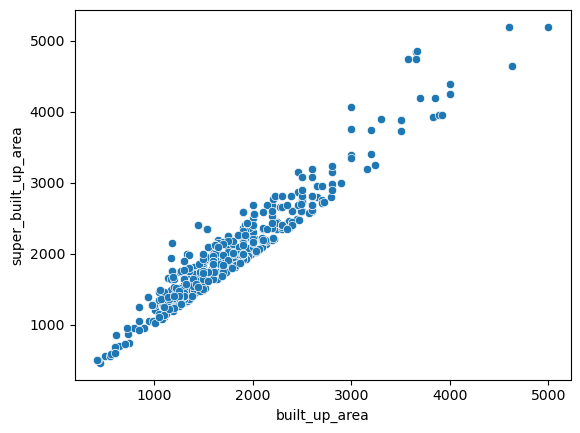

In [61]:
sns.scatterplot(
    x=df['built_up_area'],
    y=df['super_built_up_area']
)

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

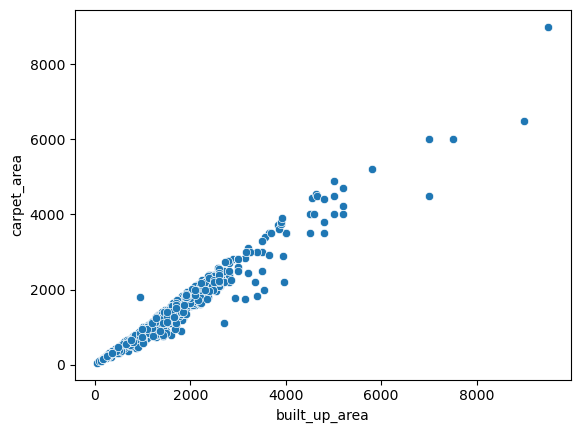

In [65]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area '])

In [67]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3551    False
3552    False
3553    False
3554    False
3555    False
Length: 3556, dtype: bool

In [73]:
# This line filters the DataFrame to keep only those rows where all three area columns have values.
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [75]:
all_present_df.shape

(530, 24)

In [ ]:
# This line calculates the median ratio of super built-up area to built-up area.

In [83]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [85]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [87]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1052289815447711 0.9009597281535565


In [89]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [91]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
13,flat,signature global synera,sector 81,0.31,7434.0,417.0,Super Built up area 417(38.74 sq.m.)Carpet are...,1.0,1.0,1,13.0,North,Relatively New,417.0,NaN,320.0,0.0,0.0,0.0,0.0,0.0,2.0,123.0,417.000000
15,flat,dlf the primus,sector 82a,1.85,10176.0,1818.0,Super Built up area 1818(168.9 sq.m.)Carpet ar...,3.0,3.0,3,15.0,East,Moderately Old,1818.0,NaN,1538.0,0.0,0.0,0.0,0.0,1.0,0.0,38.0,606.000000
22,flat,adani m2k oyster grande,sector 102,2.40,9306.0,2579.0,Super Built up area 2579(239.6 sq.m.)Carpet ar...,3.0,4.0,3+,3.0,North-East,Relatively New,2579.0,NaN,2100.0,1.0,0.0,0.0,0.0,0.0,1.0,49.0,859.666667
24,flat,vatika gurgaon,sector 83,1.33,5565.0,2390.0,Super Built up area 2390(222.04 sq.m.)Carpet a...,4.0,4.0,3,3.0,East,Relatively New,2390.0,NaN,2000.0,0.0,1.0,0.0,0.0,0.0,0.0,26.0,597.500000
67,flat,ss the leaf,sector 85,1.30,7780.0,1671.0,Super Built up area 1671(155.24 sq.m.)Carpet a...,2.0,2.0,3+,16.0,East,Relatively New,1671.0,NaN,1169.0,0.0,0.0,1.0,0.0,0.0,0.0,148.0,835.500000


In [93]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

In [95]:
df.update(sbc_df)

In [97]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1009
agePossession             0
super_built_up_area    1685
built_up_area          1551
carpet_area            1711
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [107]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [109]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3,flat,ss the leaf,sector 85,2.00,8306.0,2408.0,Super Built up area 2408(223.71 sq.m.),3.0,4.0,3,8.0,East,Relatively New,2408.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,21.0,802.666667
4,flat,orchid petals,sector 49,1.95,9974.0,1955.0,Super Built up area 1805(167.69 sq.m.),3.0,3.0,3,2.0,East,Old Property,1805.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,90.0,651.666667
6,flat,bptp terra,sector 37d,1.45,8007.0,1811.0,Super Built up area 1811(168.25 sq.m.),3.0,3.0,3,9.0,North-East,Relatively New,1811.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,107.0,603.666667
7,flat,indiabulls centrum park,sector 103,1.20,8433.0,1423.0,Super Built up area 1423(132.2 sq.m.),2.0,2.0,3,3.0,North-East,Moderately Old,1423.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,26.0,711.500000
8,flat,the close north,sector 50,3.00,11516.0,2605.0,Super Built up area 2605(242.01 sq.m.),3.0,3.0,3+,14.0,North,Old Property,2605.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,121.0,868.333333


In [111]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_

In [113]:
df.update(sb_df)

In [115]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1009
agePossession             0
super_built_up_area    1685
built_up_area           679
carpet_area            1711
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [117]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [119]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
14,flat,vatika independent floors,sector 82,1.16,6988.0,1660.0,Carpet area: 1660 (154.22 sq.m.),3.0,3.0,3+,1.0,South-East,Relatively New,NaN,NaN,1660.000000,0.0,1.0,1.0,1.0,0.0,1.0,151.0,553.333333
29,flat,godrej summit,sector 104,0.85,6894.0,1233.0,Carpet area: 1450 (134.71 sq.m.),2.0,2.0,3,12.0,NaN,Relatively New,NaN,NaN,1450.000000,1.0,0.0,0.0,0.0,1.0,0.0,61.0,616.500000
32,flat,viridian the plaza 106,sector 106,0.46,6571.0,700.0,Carpet area: 700 (65.03 sq.m.),1.0,1.0,1,18.0,NaN,New Property,NaN,NaN,700.000000,0.0,0.0,0.0,0.0,0.0,0.0,104.0,700.000000
35,flat,denso haryana housing society,manesar,0.90,4308.0,2089.0,Carpet area: 2089 (194.07 sq.m.),3.0,3.0,3+,5.0,East,Moderately Old,NaN,NaN,2089.000000,0.0,1.0,0.0,0.0,0.0,0.0,7.0,696.333333
38,flat,zara aavaas,sector 104,0.22,7309.0,301.0,Carpet area: 301.28 (27.99 sq.m.),1.0,2.0,2,2.0,NaN,New Property,NaN,NaN,301.281561,0.0,0.0,0.0,0.0,0.0,0.0,60.0,301.000000


In [123]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_

In [125]:
df.update(c_df)

In [127]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1009
agePossession             0
super_built_up_area    1685
built_up_area             0
carpet_area            1711
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

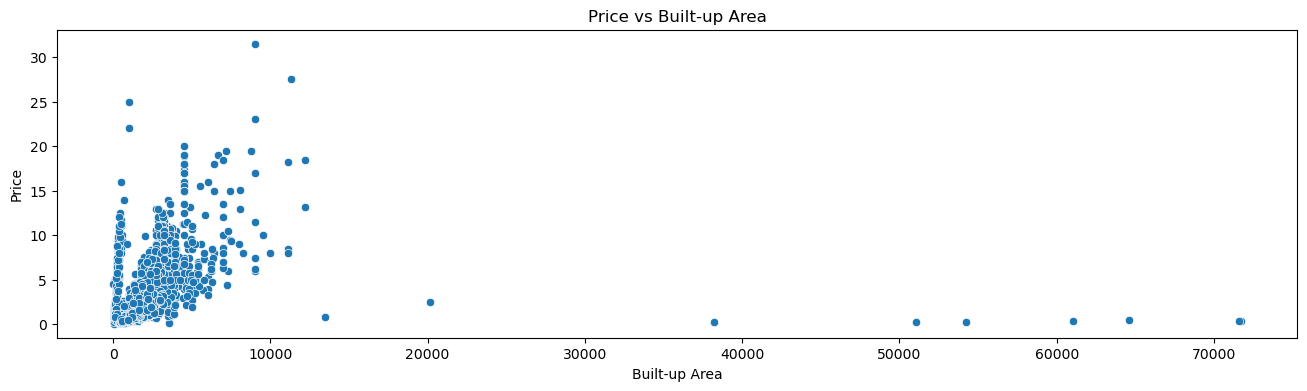

In [137]:
plt.figure(figsize=(16, 4))
sns.scatterplot(x=df['built_up_area'], y=df['price'])
plt.xlabel("Built-up Area")
plt.ylabel("Price")
plt.title("Price vs Built-up Area")
plt.show()

In [143]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [145]:
anamoly_df.sample(5)

,price,area,built_up_area
2413,3.60,1728.0,1728.0
1597,4.30,1494.0,165.0
1570,4.60,1717.0,1908.0
1955,3.25,1512.0,1512.0
1736,3.25,1449.0,1449.0


In [147]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [149]:
df.update(anamoly_df)

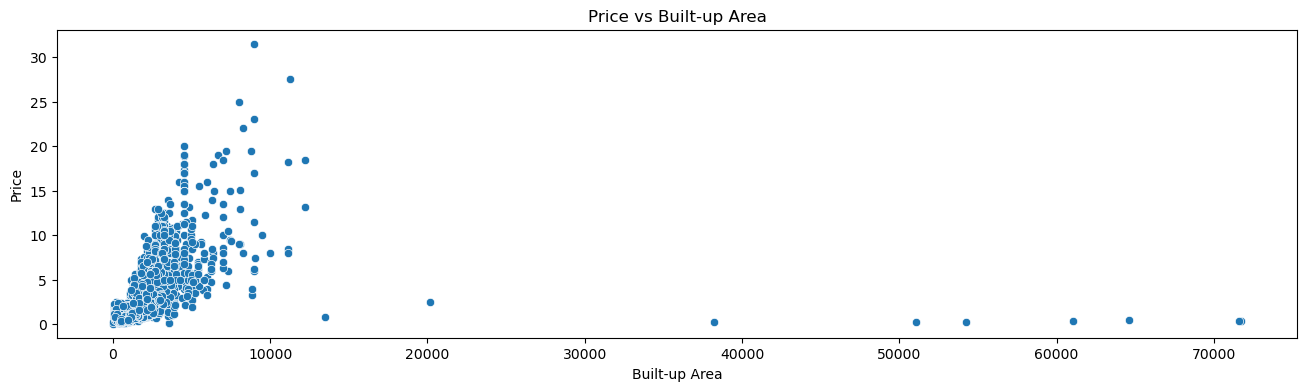

In [153]:
plt.figure(figsize=(16, 4))
sns.scatterplot(x=df['built_up_area'], y=df['price'])
plt.xlabel("Built-up Area")
plt.ylabel("Price")
plt.title("Price vs Built-up Area")
plt.show()

In [155]:
# Remove 'area','areaWithType','super_built_up_area','carpet_area','area_room_ratio' column bcz we need only built_up_area
# bcz this the area we want to take as input from user this the important column

df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [157]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,bptp astaire gardens,sector 70a,6.50,27873.0,4.0,4.0,3+,2.0,North-East,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0
1,house,central park flower valley cerise floors,sector 33,1.35,11157.0,2.0,2.0,2,4.0,East,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0
2,flat,emaar gurgaon greens,sector 102,1.45,8788.0,3.0,3.0,3,8.0,North-East,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0
3,flat,ss the leaf,sector 85,2.00,8306.0,3.0,4.0,3,8.0,East,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0
4,flat,orchid petals,sector 49,1.95,9974.0,3.0,3.0,3,2.0,East,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0


In [159]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1009
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [161]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
20,house,dlf new town heights,sector 86,2.47,7719.0,4.0,4.0,3+,NaN,West,Moderately Old,2800.0,0.0,1.0,0.0,1.0,0.0,1.0,130.0
386,house,ansal sushant lok,sector 43,10.50,27911.0,4.0,4.0,2,NaN,North-East,Old Property,3762.0,0.0,1.0,0.0,0.0,0.0,0.0,59.0
649,house,independent,sector 4,0.65,11111.0,4.0,2.0,2,NaN,NaN,Moderately Old,585.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
874,flat,experion heartsong,dwarka expressway,1.08,6150.0,3.0,3.0,0,NaN,NaN,Under Construction,1758.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1136,house,ansal sushant lok plots,sector 43,3.30,26570.0,1.0,1.0,0,NaN,NaN,Under Construction,1242.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1267,house,independent,sector 3,1.50,10288.0,3.0,3.0,0,NaN,NaN,Old Property,210.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1537,house,jacob pura,sector 12,0.35,9722.0,2.0,1.0,0,NaN,NaN,Old Property,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1589,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,2,NaN,East,Moderately Old,3240.0,0.0,1.0,1.0,1.0,0.0,0.0,88.0
1630,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,1,NaN,NaN,Relatively New,3240.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1650,house,independent,sector 26,4.60,12198.0,4.0,4.0,3+,NaN,NaN,Old Property,3771.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0


In [163]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [165]:
df['floorNum'].fillna(2.0,inplace=True)

/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_30236/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [167]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1009
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [169]:
1011/df.shape[0]

0.28430821147356583

### facing

<Axes: ylabel='count'>

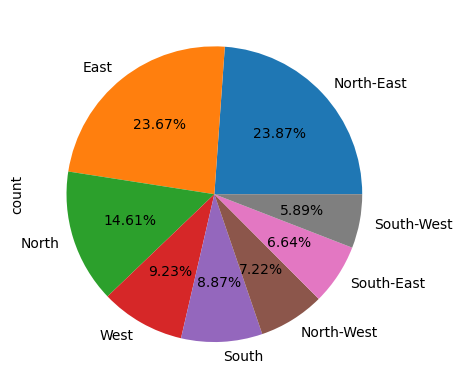

In [173]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [175]:
# We cannot predict 1000 rows values so this column is irrelevent to our model 
# 3 so it is better that we should drop this column

In [177]:
df.drop(columns=['facing'],inplace=True)

In [179]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2385,flat,ss,sector 85,1.98,8223.0,3.0,4.0,3,6.0,Relatively New,2300.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0
3542,flat,bestech park view ananda,sector 81,1.40,7735.0,3.0,3.0,3+,6.0,Relatively New,1475.0,0.0,0.0,0.0,0.0,0.0,0.0,95.0
1157,house,rwa sector 46,sector 46,4.50,24390.0,6.0,6.0,3+,3.0,Moderately Old,1845.0,0.0,0.0,1.0,0.0,0.0,1.0,80.0
1296,flat,shree vardhman flora,sector 90,0.70,5385.0,2.0,2.0,3,13.0,New Property,1176.0,1.0,0.0,0.0,0.0,0.0,0.0,15.0
1871,house,independent,sector 43,8.25,30556.0,5.0,6.0,3+,3.0,Moderately Old,2700.0,1.0,1.0,1.0,1.0,0.0,1.0,64.0


In [181]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [185]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2137,flat,NaN,sector 78,0.6,3692.0,2.0,2.0,0,2.0,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [187]:
df.drop(index=[2137],inplace=True)

In [189]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [191]:
df['agePossession'].value_counts()

agePossession
Relatively New        1611
New Property           555
Moderately Old         543
Old Property           292
Undefined              290
Under Construction     264
Name: count, dtype: int64

In [193]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
5,flat,sidhartha ncr one phase,sector 95,0.60,4800.0,2.0,2.0,3,10.0,Undefined,1250.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,flat,sare crescent parc royal greens phase 1,sector 92,0.50,5000.0,2.0,2.0,3,2.0,Undefined,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,house,shivaji nagar residential,sector 11,3.08,11407.0,6.0,4.0,2,1.0,Undefined,2700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37,flat,smart world gems,sector 89,1.20,8433.0,3.0,3.0,2,2.0,Undefined,1423.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
45,house,ansal api esencia,sector 67,1.85,8222.0,3.0,3.0,3,1.0,Undefined,278.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,house,dlf the arbour,sector 110,8.50,21519.0,4.0,4.0,3+,27.0,Undefined,3950.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0
3496,house,independent,sector 2,5.00,15385.0,6.0,6.0,2,1.0,Undefined,3611.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3515,flat,sobha smriti apartments,sector 56,0.50,8333.0,1.0,1.0,2,3.0,Undefined,667.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3544,flat,railway officers rpf society,sector 9a,1.30,5039.0,4.0,4.0,3+,9.0,Undefined,2580.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# We will find in the whole dataset for same property_type and sector 
# then we will  extract the mode of these rows ( most frequent value)
# Then will replace it by that

In [195]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [197]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [199]:
df['agePossession'].value_counts()

agePossession
Relatively New        1733
New Property           583
Moderately Old         581
Old Property           325
Under Construction     278
Undefined               55
Name: count, dtype: int64

In [ ]:
# only sector basis we are doing again to fill the rest missing value

In [201]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [203]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [205]:
df['agePossession'].value_counts()

agePossession
Relatively New        1744
Moderately Old         588
New Property           584
Old Property           328
Under Construction     278
Undefined               33
Name: count, dtype: int64

In [207]:
# only 'property_type' basis we are doing again to fill the rest missing value

In [209]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [211]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [213]:
df['agePossession'].value_counts()

agePossession
Relatively New        1746
Moderately Old         619
New Property           584
Old Property           328
Under Construction     278
Name: count, dtype: int64

In [215]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [217]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [231]:
df.shape

(3555, 18)